# Previsione della Temperatura Interna a Breve Termine tramite Support Vector Regression (SVR)

---

## Abstract
Questo notebook illustra l'applicazione delle **Support Vector Machines per la Regressione (SVR)** con kernel RBF (Radial Basis Function) per la previsione della temperatura interna a $t+10$ minuti, utilizzando dati storici non continuativi raccolti da un sensore DHT e archiviati in InfluxDB. 

Il progetto affronta le sfide tipiche dei sensori IoT reali:
1. **Dati non continuativi (Gap temporali)**: sessioni di monitoraggio isolate (4 giorni, circa 1 ora al giorno).
2. **Ingegnerizzazione dei lag temporali** senza cross-day data leakage.
3. **Ottimizzazione degli iperparametri ($C, \gamma, \epsilon$)** e validazione del modello su un giorno di test completamente separato ("Day-Holdout Split").

---

## 1. Fondamenti Teorici della Support Vector Regression (SVR)

La **Support Vector Regression (SVR)**, introdotta da Vapnik et al., è un metodo di apprendimento supervisionato. A differenza della regressione lineare dei minimi quadrati, che minimizza la somma dei quadrati degli errori, la SVR tenta di trovare una funzione $f(x)$ che si discosti al massimo di una tolleranza $\epsilon$ dai target reali $y_i$, risultando al contempo la più lineare ("piatta") possibile.

### 1.1 La Funzione di Loss $\epsilon$-Insensitive
La caratteristica fondamentale della SVR è l'uso della funzione di perdita $\epsilon$-insensitive:

$$L_{\epsilon}(y, f(x)) = \max(0, |y - f(x)| - \epsilon)$$

Questo definisce un **$\epsilon$-tubo** attorno alla funzione stimata. Qualsiasi punto di addestramento che cade all'interno del tubo ha costo (loss) pari a zero. I punti esterni al tubo pagano una penale lineare rappresentata dalle variabili di $\xi_i$ e $\xi_i^*$.

   y ^
     |          .------------------  f(x) + epsilon
     |         /      o (Support Vector fuori dal tubo: xi_i* > 0)
     |        /   o     
     |       / o   o   o  <-- (Punti interni al tubo: loss = 0)
     |      /______________________  f(x)
     |     /   o
     |    /       o (Support Vector sul bordo del tubo)
     |   /-------------------------  f(x) - epsilon
     +-----------------------------------> x

### 1.2 Formulazione Matematica 
Il problema di ottimizzazione per trovare la retta ottimale $f(x) = \langle w, x \rangle + b$ con il miglior compromesso tra "flatness" e tolleranza dell'errore si formula come:

$$\min_{w, b, \xi, \xi^*} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$$

soggetto ai vincoli:

$$\begin{cases} 
y_i - \langle w, x_i \rangle - b \le \epsilon + \xi_i \\
\langle w, x_i \rangle + b - y_i \le \epsilon + \xi_i^* \\
\xi_i, \xi_i^* \ge 0 
\end{cases}$$

Dove:
*   **$C > 0$** è la costante di regolarizzazione. Controlla il trade-off tra la morbidezza di $f(x)$ e il grado di tolleranza per deviazioni maggiori di $\epsilon$. Un valore alto di $C$ porta a un modello complesso con potenziale overfitting.
*   **$\epsilon$** definisce la larghezza del tubo. Valori più grandi di $\epsilon$ portano a modelli con meno vettori di supporto e quindi più "sparsi" e semplici.

### 1.3 Formulazione Duale e il "Kernel Trick"
Risolvendo il problema tramite i moltiplicatori di Lagrange $\alpha_i, \alpha_i^*$, e introducendo una mappatura non lineare nello spazio delle feature ad alta dimensionalità $\Phi(x)$, si ottiene la formulazione duale che dipende solo dal prodotto scalare tra i vettori. Sostituendo il prodotto scalare con una funzione di **Kernel** $K(x_i, x_j) = \langle \Phi(x_i), \Phi(x_j) \rangle$, possiamo apprendere relazioni non lineari complesse senza calcolare esplicitamente la proiezione multidimensionale.

La funzione di decisione finale diventa:

$$f(x) = \sum_{i=1}^{n} (\alpha_i - \alpha_i^*) K(x_i, x) + b$$

I campioni $x_i$ per cui $\alpha_i - \alpha_i^* \neq 0$ sono definiti **Vettori di Supporto (Support Vectors)**.

Utilizzeremo il kernel **Radial Basis Function (RBF)** (gaussiano):

$$K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$$

Dove **$\gamma$ (gamma)** definisce il raggio di influenza di ogni singolo vettore di supporto. Un valore elevato di $\gamma$ restringe l'influenza, portando a curve molto sensibili al rumore locale (overfitting).

## 2. Architettura della Pipeline dei Dati e Prevenzione del Leakage

Il dataset reale presenta **interruzioni (gap) temporali significativi** (4 giorni differenti, con acquisizioni di circa un'ora ciascuna). I modelli di regressione classici per serie storiche assumono una sequenza temporale uniforme e ininterrotta.

### 2.1 Formulazione del problema come Supervised Learning
Risolviamo questa limitazione trasformando la serie storica in un dataset tabulare di apprendimento supervisionato.
Dato l'istante $t$, definiamo:
*   **Target (y)**: La temperatura futura $T_{t+10}$.
*   **Features (X)**: Un insieme di lag temporali $[T_t, H_t, P_t, T_{t-1}, T_{t-5}, H_{t-5}]$ e indicatori di trend come la derivata discreta $\Delta T_{5m} = T_t - T_{t-5}$.

### 2.2 Isolamento delle Sessioni (No Leakage)
Quando si calcolano i lag (es. $t-5$ minuti) e il target spostato ($t+10$ minuti), **non dobbiamo mai scavalcare il confine di un giorno**. Ad esempio, il valore $T_{t-5}$ del primo minuto del Giorno 2 non deve assolutamente fare riferimento al Giorno 1.
La pipeline si occuperà di:
1. Dividere il dataset per giorni (sessioni autonome).
2. Per ogni sessione, calcolare i lag temporali e il target.
3. Rimuovere i primi 5 record di ogni sessione (perché i lag $t-5$ non sono definiti) e gli ultimi 10 record (perché il target $t+10$ cade nel vuoto).
4. Riunire i campioni puliti nel dataset finale.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv
from utils import fetch_influx_data, query, load_and_clean_data

Configurazione caricata correttamente!
 URL: http://192.168.135.209:8086 |  Bucket: monitoraggio_pi


In [3]:
import pandas as pd

days = [
    "data/days/10-luglio-2026.csv" , #non puliti 
    "data/days/11-luglio-2026.csv",  # non puliti
    "data/days/18-luglio-2026.csv", # non puliti
    #"data/days/25-luglio-2026.csv", # already cleaned & resampled
    #"data/days/30-luglio-2026.csv", # already cleaned & resampled
]

dfs = []
for d in days:
    dfs.append(load_and_clean_data(d))


#dfs.append(pd.read_csv("data/days/25-luglio-2026.csv"))
#dfs.append(pd.read_csv("data/days/30-luglio-2026.csv"))

df_final = pd.concat (dfs)
df_final


_field,percepita,temperatura,umidita
_time,,,
2026-07-10 16:20:00+00:00,33.600000,33.550000,35.000000
2026-07-10 16:21:00+00:00,33.800000,33.800000,34.000000
2026-07-10 16:22:00+00:00,33.800000,33.800000,34.000000
2026-07-10 16:23:00+00:00,33.800000,33.800000,34.000000
2026-07-10 16:24:00+00:00,34.000000,33.800000,35.000000
...,...,...,...
2026-07-18 09:05:00+00:00,34.700000,33.300000,42.000000
2026-07-18 09:06:00+00:00,34.345455,33.118182,41.727273
2026-07-18 09:07:00+00:00,34.100000,32.800000,43.000000


In [4]:
def load_raw_percepita(path):
    df = pd.read_csv(path)
    
    # valutare se tenere solo 'percepita'
    
    # converti _time in datetime e usalo come indice
    df["_time"] = pd.to_datetime(df["_time"], utc=True, errors='coerce')
    df = df.set_index("_time")
    
    # tieni solo il valore, rinominandolo 'percepita'
    #df = df[["_value"]].rename(columns={"_value": "percepita"})
    
    return df

days_raw = [
    "data/days/25-luglio-2026.csv",
    "data/days/30-luglio-2026.csv",
    "data/days/09-agosto-2026.csv",
]

dfs_raw = [load_raw_percepita(d) for d in days_raw]

df_final = pd.concat(dfs + dfs_raw)

cols = ['percepita', 'temperatura', 'umidita']
df_final[cols]

,percepita,temperatura,umidita
_time,,,
2026-07-10 16:20:00+00:00,33.6,33.55,35.0
2026-07-10 16:21:00+00:00,33.8,33.80,34.0
2026-07-10 16:22:00+00:00,33.8,33.80,34.0
2026-07-10 16:23:00+00:00,33.8,33.80,34.0
2026-07-10 16:24:00+00:00,34.0,33.80,35.0
...,...,...,...
2026-08-09 09:34:49.209956+00:00,34.6,34.20,35.0
2026-08-09 09:34:54.470097+00:00,34.6,34.20,35.0
2026-08-09 09:34:59.741059+00:00,34.6,34.20,35.0


In [5]:
df_final[cols].to_csv("data/days/current_data_cleaned.csv")

In [6]:
data = pd.read_csv("data/days/current_data_cleaned.csv")
data.loc[data.count() -1]

,_time,percepita,temperatura,umidita
3327,2026-08-09 09:35:10.271187+00:00,34.6,34.2,35.0
3327,2026-08-09 09:35:10.271187+00:00,34.6,34.2,35.0
3327,2026-08-09 09:35:10.271187+00:00,34.6,34.2,35.0
3327,2026-08-09 09:35:10.271187+00:00,34.6,34.2,35.0


In [7]:
data.loc[data.count() -1]

,_time,percepita,temperatura,umidita
3327,2026-08-09 09:35:10.271187+00:00,34.6,34.2,35.0
3327,2026-08-09 09:35:10.271187+00:00,34.6,34.2,35.0
3327,2026-08-09 09:35:10.271187+00:00,34.6,34.2,35.0
3327,2026-08-09 09:35:10.271187+00:00,34.6,34.2,35.0


In [8]:
data.loc[0]

_time          2026-07-10 16:20:00+00:00
percepita                           33.6
temperatura                        33.55
umidita                             35.0
Name: 0, dtype: object

In [9]:
data

,_time,percepita,temperatura,umidita
0,2026-07-10 16:20:00+00:00,33.6,33.55,35.0
1,2026-07-10 16:21:00+00:00,33.8,33.80,34.0
2,2026-07-10 16:22:00+00:00,33.8,33.80,34.0
3,2026-07-10 16:23:00+00:00,33.8,33.80,34.0
4,2026-07-10 16:24:00+00:00,34.0,33.80,35.0
...,...,...,...,...
3323,2026-08-09 09:34:49.209956+00:00,34.6,34.20,35.0
3324,2026-08-09 09:34:54.470097+00:00,34.6,34.20,35.0
3325,2026-08-09 09:34:59.741059+00:00,34.6,34.20,35.0
3326,2026-08-09 09:35:05.001349+00:00,34.6,34.20,35.0


In [10]:
df_prepared = data.copy()

# rimuovi eventuali colonne duplicate, tenendo la prima occorrenza
df_prepared = df_prepared.loc[:, ~df_prepared.columns.duplicated()]

df_prepared["_time"] = pd.to_datetime(df_prepared["_time"], format='ISO8601' )

# controlla quante righe sono finite in NaT (dovrebbero essere 0 o pochissime)
print("Righe con _time non convertito:", df_prepared["_time"].isna().sum())

df_prepared = df_prepared.set_index("_time")
df_prepared = df_prepared[["percepita", "temperatura", "umidita"]].sort_index()

print(df_prepared.head(3))
print(df_prepared.tail(3))

Righe con _time non convertito: 0
                           percepita  temperatura  umidita
_time                                                     
2026-07-10 16:20:00+00:00       33.6        33.55     35.0
2026-07-10 16:21:00+00:00       33.8        33.80     34.0
2026-07-10 16:22:00+00:00       33.8        33.80     34.0
                                  percepita  temperatura  umidita
_time                                                            
2026-08-09 09:34:59.741059+00:00       34.6         34.2     35.0
2026-08-09 09:35:05.001349+00:00       34.6         34.2     35.0
2026-08-09 09:35:10.271187+00:00       34.6         34.2     35.0


In [11]:
df_prepared.head(15)

,percepita,temperatura,umidita
_time,,,
2026-07-10 16:20:00+00:00,33.600000,33.550000,35.000000
2026-07-10 16:21:00+00:00,33.800000,33.800000,34.000000
2026-07-10 16:22:00+00:00,33.800000,33.800000,34.000000
2026-07-10 16:23:00+00:00,33.800000,33.800000,34.000000
2026-07-10 16:24:00+00:00,34.000000,33.800000,35.000000
2026-07-10 16:25:00+00:00,33.927273,33.800000,34.636364
2026-07-10 16:26:00+00:00,33.854545,33.800000,34.272727
2026-07-10 16:27:00+00:00,33.818182,33.800000,34.090909
2026-07-10 16:28:00+00:00,33.883333,33.800000,34.416667


In [12]:
df_prepared.tail(15)

,percepita,temperatura,umidita
_time,,,
2026-08-09 09:33:56.557756+00:00,34.8,34.2,36.0
2026-08-09 09:34:01.819468+00:00,34.8,34.2,36.0
2026-08-09 09:34:07.088911+00:00,34.8,34.2,36.0
2026-08-09 09:34:12.349034+00:00,34.8,34.2,36.0
2026-08-09 09:34:17.618748+00:00,34.8,34.2,36.0
2026-08-09 09:34:22.878852+00:00,34.8,34.2,36.0
2026-08-09 09:34:28.148841+00:00,34.8,34.2,36.0
2026-08-09 09:34:33.410721+00:00,34.6,34.2,35.0
2026-08-09 09:34:38.680188+00:00,34.8,34.2,36.0


Dataframe ML pronto. Righe totali utili per l'addestramento: 408
Giorni disponibili: [datetime.date(2026, 7, 10), datetime.date(2026, 7, 11), datetime.date(2026, 7, 18), datetime.date(2026, 7, 25), datetime.date(2026, 7, 30), datetime.date(2026, 8, 9)]
Giorni di addestramento (Train): [datetime.date(2026, 7, 10), datetime.date(2026, 7, 11), datetime.date(2026, 7, 18), datetime.date(2026, 7, 25), datetime.date(2026, 7, 30)]
Giorno di verifica (Test): 2026-08-09

Avvio dell'addestramento SVR con ottimizzazione iperparametri...
Migliori parametri trovati: {'C': 10, 'epsilon': 1e-05, 'gamma': 0.1}

--- METRICHE DI PERFORMANCE SUL TEST SET (Giorno Holdout) ---
Mean Absolute Error (MAE): 0.2669 °C
Root Mean Squared Error (RMSE): 0.3167 °C
R² Score: -5.9122


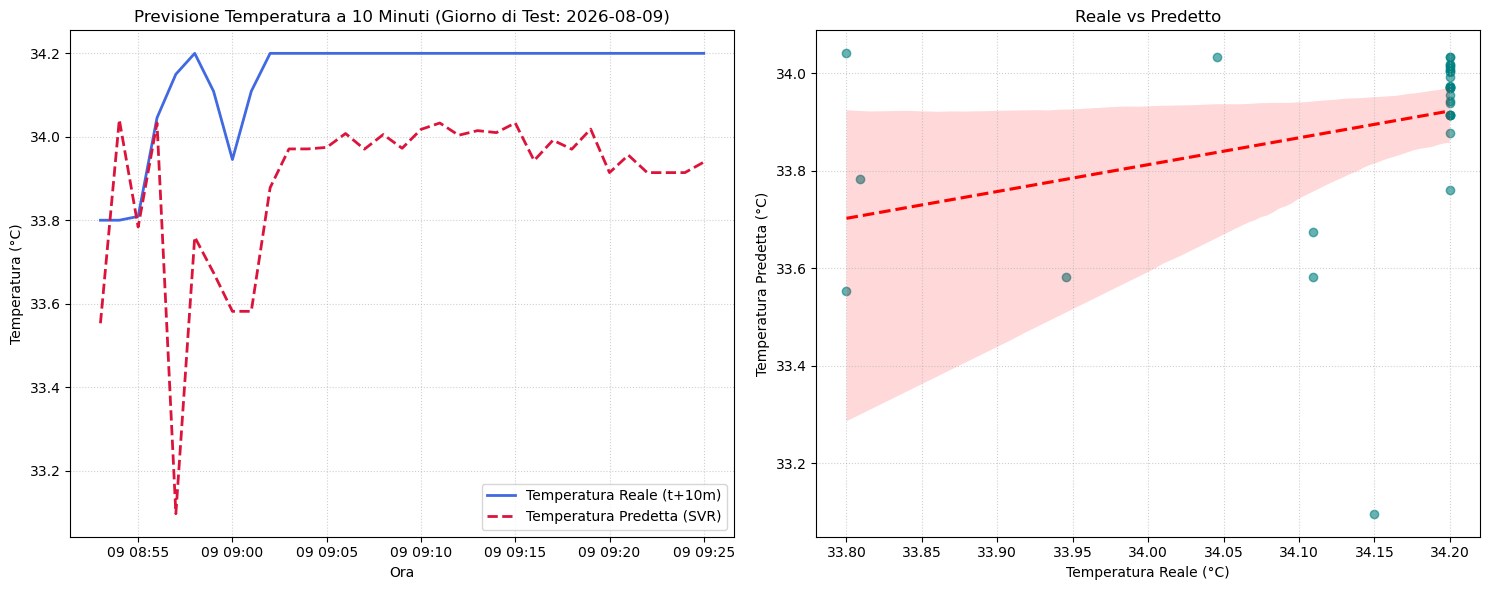

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# 1. PREPARAZIONE DELLE FEATURE E DEL TARGET 
# =====================================================================
# Usiamo direttamente df_prepared con _time come indice.
# Raggruppiamo per data usando df_prepared.index.date per isolare i giorni.
processed_days = []

for date, group in df_prepared.groupby(df_prepared.index.date):
    # Ordiniamo temporalmente la singola giornata
    group = group.sort_index()
    
    # Uniformiamo a step di 1 minuto e interpoliamo eventuali piccoli buchi interni
    group_resampled = group.resample("1min").mean().interpolate(method="linear")
    
    # Definiamo il Target: Temperatura a t+10 minuti (10 righe nel futuro)
    group_resampled["target"] = group_resampled["temperatura"].shift(-10)
    
    # Creiamo le Feature storiche (Lag) per il momento t
    group_resampled["temp_lag_1"] = group_resampled["temperatura"].shift(1)
    group_resampled["temp_lag_2"] = group_resampled["temperatura"].shift(2)
    group_resampled["temp_lag_5"] = group_resampled["temperatura"].shift(5)
    group_resampled["umidita_lag_5"] = group_resampled["umidita"].shift(5)
    group_resampled["percepita_lag_5"] = group_resampled["percepita"].shift(5)
    
    # Feature di Trend: differenza di temperatura negli ultimi 5 minuti
    group_resampled["temp_diff_5m"] = group_resampled["temperatura"] - group_resampled["temp_lag_5"]
    
    # Memorizziamo la data corrente per lo split successivo
    group_resampled["date"] = date
    
    # dropna() rimuove i primi 5 record (dove i lag non esistono) 
    # e gli ultimi 10 record (dove il target t+10 cadrebbe nel vuoto) per OGNI giorno
    processed_days.append(group_resampled.dropna())

# Uniamo tutte le sessioni pulite in un unico DataFrame per il Machine Learning
df_ml = pd.concat(processed_days)

print(f"Dataframe ML pronto. Righe totali utili per l'addestramento: {len(df_ml)}")

# =====================================================================
# 2. SPLIT TRAINING E TESTING (DAY-HOLDOUT SPLIT)
# =====================================================================
# Otteniamo la lista ordinata dei giorni disponibili
unique_days = sorted(df_ml["date"].unique())
print("Giorni disponibili:", unique_days)

# Usiamo i primi 4 giorni per il Training e l'ultimo giorno per il Testing
train_days = unique_days[:-1]
test_day = unique_days[-1]

print(f"Giorni di addestramento (Train): {train_days}")
print(f"Giorno di verifica (Test): {test_day}")

train_data = df_ml[df_ml["date"].isin(train_days)]
test_data = df_ml[df_ml["date"] == test_day]

# Definiamo le colonne da usare come Feature (X) e il Target (y)
feature_cols = [
    "temperatura", "umidita", "percepita", 
    "temp_lag_1", "temp_lag_2", "temp_lag_5", 
    "umidita_lag_5", "percepita_lag_5", "temp_diff_5m"
]

X_train = train_data[feature_cols]
y_train = train_data["target"]

X_test = test_data[feature_cols]
y_test = test_data["target"]

# =====================================================================
# 3. STANDARDIZZAZIONE DEI DATI (PER SVR)
# =====================================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scaliamo le feature
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scaliamo il target (SVR con kernel RBF richiede anche il target normalizzato)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

# =====================================================================
# 4. ADDESTRAMENTO SVR CON OTTIMIZZAZIONE IPERPARAMETRI (GRID SEARCH)
# =====================================================================
print("\nAvvio dell'addestramento SVR con ottimizzazione iperparametri...")

param_grid = {
    'C': [0.001, 0.1, 1, 10, 100],            # Regolarizzazione
    'gamma': ['scale', 'auto', 0.1 ],   # Raggio di influenza del kernel RBF
    'epsilon': [ 0.00001, 0.0001, 0.001, 0.01, 0.1, 0.2]        # Tolleranza del tubo d'errore
}

# Usiamo una 5-Fold Cross Validation sul training set
grid_search = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train_scaled)
best_svr = grid_search.best_estimator_

print("Migliori parametri trovati:", grid_search.best_params_)

# =====================================================================
# 5. PREDIZIONE E VALUTAZIONE
# =====================================================================
# Prediciamo sul test set (giorno holdout)
y_pred_scaled = best_svr.predict(X_test_scaled)

# Riportiamo le predizioni e i target reali alla scala originale (°C)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Calcolo delle metriche
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- METRICHE DI PERFORMANCE SUL TEST SET (Giorno Holdout) ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} °C")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} °C")
print(f"R² Score: {r2:.4f}")

# =====================================================================
# 6. VISUALIZZAZIONE DEI RISULTATI
# =====================================================================
plt.figure(figsize=(15, 6))

# Grafico 1: Confronto Temporale sul Giorno di Test
plt.subplot(1, 2, 1)
plt.plot(test_data.index, y_test, label="Temperatura Reale (t+10m)", color="royalblue", linewidth=2)
plt.plot(test_data.index, y_pred, label="Temperatura Predetta (SVR)", color="crimson", linestyle="--", linewidth=2)
plt.title(f"Previsione Temperatura a 10 Minuti (Giorno di Test: {test_day})")
plt.xlabel("Ora")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

# Grafico 2: Scatter Plot Reale vs Predetto
plt.subplot(1, 2, 2)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6, 'color':'teal'}, line_kws={'color':'red', 'ls':'--'})
plt.title("Reale vs Predetto")
plt.xlabel("Temperatura Reale (°C)")
plt.ylabel("Temperatura Predetta (°C)")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import pandas as pd

#Se volessi predirre la temperatura tra 10 minuti

#Farei un query da influxDb per beccarmi il vettore da dare in pasto al modello
ultimi_dati = pd.DataFrame({
    "temperatura": [33.80, 33.80, 33.90, 34.00, 34.00, 34.15], # t-5, t-4, t-3, t-2, t-1, t
    "umidita":     [35.00, 35.00, 34.80, 34.50, 34.20, 34.00],
    "percepita":   [34.00, 34.00, 34.10, 34.20, 34.20, 34.30]
}, index=pd.date_range(start="2026-08-09 16:55:00", end="2026-08-09 17:00:00", freq="1min"))

print("Dati degli ultimi 6 minuti:")
print(ultimi_dati)

# --- STEP 3: Estrazione del vettore di Feature per l'istante t (17:00) ---
t_attuale = ultimi_dati.index[-1] # 17:00:00

# Valori a t
temp_t = ultimi_dati.loc[t_attuale, "temperatura"]
umidita_t = ultimi_dati.loc[t_attuale, "umidita"]
percepita_t = ultimi_dati.loc[t_attuale, "percepita"]

# Lag storici rispetto a t
temp_lag_1 = ultimi_dati.iloc[-2]["temperatura"] # t-1 (16:59)
temp_lag_2 = ultimi_dati.iloc[-3]["temperatura"] # t-2 (16:58)
temp_lag_5 = ultimi_dati.iloc[-6]["temperatura"] # t-5 (16:55)

umidita_lag_5 = ultimi_dati.iloc[-6]["umidita"]   # t-5 (16:55)
percepita_lag_5 = ultimi_dati.iloc[-6]["percepita"] # t-5 (16:55)

# Trend negli ultimi 5 minuti
temp_diff_5m = temp_t - temp_lag_5

# NOTA: identico a quello del training set
X_current = pd.DataFrame([{
    "temperatura": temp_t,
    "umidita": umidita_t,
    "percepita": percepita_t,
    "temp_lag_1": temp_lag_1,
    "temp_lag_2": temp_lag_2,
    "temp_lag_5": temp_lag_5,
    "umidita_lag_5": umidita_lag_5,
    "percepita_lag_5": percepita_lag_5,
    "temp_diff_5m": temp_diff_5m
}])

# --- STEP 4: Scaling ---
# Utilizziamo gli scaler addestrati in precedenza
X_current_scaled = scaler_X.transform(X_current)

# --- STEP 5: Predizione con SVR e Inverse Scaling ---
y_pred_scaled = best_svr.predict(X_current_scaled)
y_pred_celsius = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()[0]

# --- RISULTATO ---
ora_predizione = t_attuale + pd.Timedelta(minutes=10)
print("\n=======================================================")
print(f"Ora Corrente (t): {t_attuale.strftime('%H:%M:%S')}")
print(f"Temperatura Corrente: {temp_t} °C")
print("-------------------------------------------------------")
print(f"Previsione per le {ora_predizione.strftime('%H:%M:%S')} (t+10m):")
print(f"--> {y_pred_celsius:.2f} °C")
print("=======================================================")

Dati degli ultimi 6 minuti:
                     temperatura  umidita  percepita
2026-08-09 16:55:00        33.80     35.0       34.0
2026-08-09 16:56:00        33.80     35.0       34.0
2026-08-09 16:57:00        33.90     34.8       34.1
2026-08-09 16:58:00        34.00     34.5       34.2
2026-08-09 16:59:00        34.00     34.2       34.2
2026-08-09 17:00:00        34.15     34.0       34.3

Ora Corrente (t): 17:00:00
Temperatura Corrente: 34.15 °C
-------------------------------------------------------
Previsione per le 17:10:00 (t+10m):
--> 33.89 °C


In [15]:
import pandas as pd
import numpy as np
from utils import fetch_influx_data, INFLUX_BUCKET

# =====================================================================
# 1. COSTRUZIONE DELLA QUERY FLUX ED ESECUZIONE
# =====================================================================
# Chiediamo gli ultimi 20 minuti per essere sicuri di avere una finestra 
# temporale robusta per il resampling a 1 minuto.
real_time_query = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -20m)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

print("Interrogazione di InfluxDB in corso...")
df_raw = fetch_influx_data(real_time_query)

if df_raw.empty:
    raise ValueError("Nessun dato ricevuto da InfluxDB! Verifica che il sensore stia inviando letture.")

# =====================================================================
# 2. PULIZIA E RESAMPLING IN TEMPO REALE
# =====================================================================
# Copia e rimozione eventuali colonne duplicate
df_rt = df_raw.copy()
df_rt = df_rt.loc[:, ~df_rt.columns.duplicated()]

# Allineamento indice temporale
df_rt["_time"] = pd.to_datetime(df_rt["_time"], utc=True)
df_rt = df_rt.set_index("_time")

# Selezioniamo solo le colonne principali e ordiniamo l'indice
df_rt = df_rt[["percepita", "temperatura", "umidita"]].sort_index()

# Resampling a 1 minuto per allineare i dati ed eliminare jitter temporali
df_rt_resampled = df_rt.resample("1min").mean().interpolate(method="linear")

# Estraiamo gli ultimi 6 minuti consecutivi (da t-5 a t) per calcolare le feature
df_window = df_rt_resampled.tail(6)

if len(df_window) < 6:
    raise ValueError(f"Dati insufficienti dopo il resampling (ricevute solo {len(df_window)} righe). Assicurati che il sensore sia attivo.")

print("\nFinestra temporale estratta (ultimi 6 minuti):")
print(df_window)

# =====================================================================
# 3. ESTRAZIONE DELLE FEATURE PER L'ISTANTE t (ORA ATTUALE)
# =====================================================================
t_attuale = df_window.index[-1]

# Valori correnti a t
temp_t = df_window.loc[t_attuale, "temperatura"]
umidita_t = df_window.loc[t_attuale, "umidita"]
percepita_t = df_window.loc[t_attuale, "percepita"]

# Lag storici rispetto a t (usiamo .iloc con indici negativi per sicurezza posizionale)
temp_lag_1 = df_window.iloc[-2]["temperatura"]      # t-1 (1 minuto fa)
temp_lag_2 = df_window.iloc[-3]["temperatura"]      # t-2 (2 minuti fa)
temp_lag_5 = df_window.iloc[-6]["temperatura"]      # t-5 (5 minuti fa)

umidita_lag_5 = df_window.iloc[-6]["umidita"]        # t-5 (5 minuti fa)
percepita_lag_5 = df_window.iloc[-6]["percepita"]    # t-5 (5 minuti fa)

# Calcolo del Trend negli ultimi 5 minuti
temp_diff_5m = temp_t - temp_lag_5

# Costruiamo il vettore delle feature (ordine identico a quello di addestramento)
X_rt = pd.DataFrame([{
    "temperatura": temp_t,
    "umidita": umidita_t,
    "percepita": percepita_t,
    "temp_lag_1": temp_lag_1,
    "temp_lag_2": temp_lag_2,
    "temp_lag_5": temp_lag_5,
    "umidita_lag_5": umidita_lag_5,
    "percepita_lag_5": percepita_lag_5,
    "temp_diff_5m": temp_diff_5m
}])

# =====================================================================
# 4. SCALING E PREDIZIONE
# =====================================================================
# Scaliamo le feature usando lo scaler_X addestrato
X_rt_scaled = scaler_X.transform(X_rt)

# Predizione scalata
y_rt_pred_scaled = best_svr.predict(X_rt_scaled)

# Decodifica della predizione in gradi Celsius reali tramite lo scaler_y
y_rt_pred = scaler_y.inverse_transform(y_rt_pred_scaled.reshape(-1, 1)).flatten()[0]

# =====================================================================
# 5. OUTPUT DEI RISULTATI
# =====================================================================
ora_predetta = t_attuale + pd.Timedelta(minutes=10)

print("\n" + "="*60)
print(f" STATO ATTUALE ({t_attuale.strftime('%H:%M:%S')} UTC)")
print(f"  • Temperatura Interna: {temp_t:.2f} °C")
print(f"  • Umidità:             {umidita_t:.2f} %")
print(f"  • Temp. Percepita:     {percepita_t:.2f} °C")
print(f"  • Trend (ultimi 5m):   {temp_diff_5m:+.2f} °C")
print("-"*60)
print(f" PREVISIONE SVR TRA 10 MINUTI ({ora_predetta.strftime('%H:%M:%S')} UTC):")
print(f"  --> Temperatura Stimata: {y_rt_pred:.2f} °C")
print("="*60)

Interrogazione di InfluxDB in corso...

Finestra temporale estratta (ultimi 6 minuti):
                           percepita  temperatura    umidita
_time                                                       
2026-08-09 09:02:00+00:00  34.000000    33.800000  35.000000
2026-08-09 09:03:00+00:00  34.000000    33.800000  35.000000
2026-08-09 09:04:00+00:00  34.000000    33.800000  35.000000
2026-08-09 09:05:00+00:00  34.009091    33.809091  35.000000
2026-08-09 09:06:00+00:00  34.381818    34.045455  35.181818
2026-08-09 09:07:00+00:00  34.490909    34.145455  35.000000

 STATO ATTUALE (09:07:00 UTC)
  • Temperatura Interna: 34.15 °C
  • Umidità:             35.00 %
  • Temp. Percepita:     34.49 °C
  • Trend (ultimi 5m):   +0.35 °C
------------------------------------------------------------
 PREVISIONE SVR TRA 10 MINUTI (09:17:00 UTC):
  --> Temperatura Stimata: 33.89 °C


In [15]:
import joblib
from datetime import datetime
import sklearn

# =====================================================================
# 7. EXPORT DEL MODELLO E DI TUTTI I COMPONENTI NECESSARI
# =====================================================================

model_bundle = {
    "model": best_svr,
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
    "feature_cols": feature_cols,
    "best_params": grid_search.best_params_,
    "metrics": {"mae": mae, "rmse": rmse, "r2": r2},
    "sklearn_version": sklearn.__version__,
    "trained_on": str(datetime.now()),
    "train_days": [str(d) for d in train_days],
    "test_day": str(test_day),
}

joblib.dump(model_bundle, "svr_temperatura_bundle.joblib")
print("Modello e componenti salvati in svr_temperatura_bundle.joblib")

Modello e componenti salvati in svr_temperatura_bundle.joblib


In [16]:
import joblib
import numpy as np

bundle = joblib.load("svr_temperatura_bundle.joblib")

model = bundle["model"]
scaler_X = bundle["scaler_X"]
scaler_y = bundle["scaler_y"]
feature_cols = bundle["feature_cols"]

print("Parametri del modello caricato:", bundle["best_params"])
print("Metriche in fase di training:", bundle["metrics"])

def predict_temperature(nuovo_df):
    """
    nuovo_df: DataFrame con le stesse colonne di feature_cols,
    già calcolate (lag, diff, ecc.) per le nuove righe da predire.
    """
    X_new = nuovo_df[feature_cols]
    X_new_scaled = scaler_X.transform(X_new)
    y_pred_scaled = model.predict(X_new_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    return y_pred

# Esempio d'uso:
# predizioni = predict_temperature(X_test)

Parametri del modello caricato: {'C': 10, 'epsilon': 1e-05, 'gamma': 0.1}
Metriche in fase di training: {'mae': 0.266903631738367, 'rmse': np.float64(0.3166954334591095), 'r2': -5.9121556210361526}
